# NuScenes Trajectory-Only Model Comparison

This notebook compares trajectory-only prediction baselines on the nuScenes mini dataset.

Models:
- Constant Velocity
- Linear Regression
- Ridge Regression
- MLP
- GRU
- LSTM
- Transformer

Metrics:
- ADE: Average Displacement Error
- FDE: Final Displacement Error

In [18]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

if os.path.basename(os.getcwd()) != "notebooks":
    PROJECT_ROOT = os.getcwd()

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "final_report")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULTS_ROOT = os.path.join(PROJECT_ROOT, "outputs", "results")
PLOTS_ROOT = os.path.join(PROJECT_ROOT, "outputs", "plots")

print("Project root:", PROJECT_ROOT)
print("Results root:", RESULTS_ROOT)
print("Plots root:", PLOTS_ROOT)
print("Final report output:", OUTPUT_DIR)

Project root: /workspaces/nuscenes_trajectory_demo
Results root: /workspaces/nuscenes_trajectory_demo/outputs/results
Plots root: /workspaces/nuscenes_trajectory_demo/outputs/plots
Final report output: /workspaces/nuscenes_trajectory_demo/outputs/final_report


In [19]:
summary_paths = sorted(glob.glob(os.path.join(RESULTS_ROOT, "*", "*_summary.csv")))

if len(summary_paths) == 0:
    raise FileNotFoundError(
        f"No summary CSV files found in {RESULTS_ROOT}. "
        "Run the baseline scripts first."
    )

summary_paths

['/workspaces/nuscenes_trajectory_demo/outputs/results/constant_velocity/constant_velocity_summary.csv',
 '/workspaces/nuscenes_trajectory_demo/outputs/results/gru/gru_summary.csv',
 '/workspaces/nuscenes_trajectory_demo/outputs/results/linear_regression/linear_regression_summary.csv',
 '/workspaces/nuscenes_trajectory_demo/outputs/results/lstm/lstm_summary.csv',
 '/workspaces/nuscenes_trajectory_demo/outputs/results/mlp/mlp_summary.csv',
 '/workspaces/nuscenes_trajectory_demo/outputs/results/transformer/transformer_summary.csv']

In [20]:
all_results = []

for path in summary_paths:
    df = pd.read_csv(path)
    model_group = os.path.basename(os.path.dirname(path))
    df["model_group"] = model_group
    df["summary_path"] = path
    all_results.append(df)

combined_df = pd.concat(all_results, ignore_index=True, sort=False)

front_cols = ["model_group", "method", "ade", "fde", "num_samples"]
other_cols = [c for c in combined_df.columns if c not in front_cols]
combined_df = combined_df[front_cols + other_cols]
combined_df["raw_method"] = combined_df["method"]

def make_display_method(row):
    method = str(row["method"])
    if row["model_group"] == "transformer" and "ff_" not in method:
        if "dim_feedforward" in row.index and pd.notna(row.get("dim_feedforward")):
            return f"{method}_ff_{int(row['dim_feedforward'])}"
    return method

combined_df["display_method"] = combined_df.apply(make_display_method, axis=1)

combined_df = combined_df.sort_values("ade").reset_index(drop=True)

combined_csv_path = os.path.join(OUTPUT_DIR, "combined_all_saved_results.csv")
combined_df.to_csv(combined_csv_path, index=False)

combined_df

,model_group,method,ade,fde,num_samples,summary_path,hidden_dim,num_layers,epochs,lr,dropout,alpha,d_model,nhead,dim_feedforward,raw_method,display_method
0,gru,gru_hidden_256_layers_3,0.967729,2.143922,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,256.0,3.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,gru_hidden_256_layers_3,gru_hidden_256_layers_3
1,lstm,lstm_hidden_128_layers_3,0.978108,2.180802,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,128.0,3.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,lstm_hidden_128_layers_3,lstm_hidden_128_layers_3
2,lstm,lstm_hidden_256_layers_2,0.994427,2.181335,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,256.0,2.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,lstm_hidden_256_layers_2,lstm_hidden_256_layers_2
3,gru,gru_hidden_128_layers_3,0.997072,2.203734,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,128.0,3.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,gru_hidden_128_layers_3,gru_hidden_128_layers_3
4,gru,gru_hidden_128_layers_2,1.003328,2.240927,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,128.0,2.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,gru_hidden_128_layers_2,gru_hidden_128_layers_2
5,lstm,lstm_hidden_128_layers_1,1.015841,2.294535,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,128.0,1.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,lstm_hidden_128_layers_1,lstm_hidden_128_layers_1
6,lstm,lstm_hidden_256_layers_1,1.033222,2.308626,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,256.0,1.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,lstm_hidden_256_layers_1,lstm_hidden_256_layers_1
7,lstm,lstm_hidden_256_layers_3,1.046641,2.267082,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,256.0,3.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,lstm_hidden_256_layers_3,lstm_hidden_256_layers_3
8,lstm,lstm_hidden_64_layers_1,1.060962,2.384914,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,64.0,1.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,lstm_hidden_64_layers_1,lstm_hidden_64_layers_1
9,gru,gru_hidden_128_layers_1,1.061649,2.365661,704,/workspaces/nuscenes_trajectory_demo/outputs/r...,128.0,1.0,100.0,0.0010,0.1,NaN,NaN,NaN,NaN,gru_hidden_128_layers_1,gru_hidden_128_layers_1


### Best models by ADE and FDE

The best model by ADE can differ from the best model by FDE.

In [21]:
best_ade_by_group = (
    combined_df
    .sort_values("ade")
    .groupby("model_group", as_index=False)
    .first()
    .sort_values("ade")
    .reset_index(drop=True)
)

best_fde_by_group = (
    combined_df
    .sort_values("fde")
    .groupby("model_group", as_index=False)
    .first()
    .sort_values("fde")
    .reset_index(drop=True)
)

best_ade_path = os.path.join(OUTPUT_DIR, "best_ade_by_model_group.csv")
best_fde_path = os.path.join(OUTPUT_DIR, "best_fde_by_model_group.csv")

best_ade_by_group.to_csv(best_ade_path, index=False)
best_fde_by_group.to_csv(best_fde_path, index=False)

print("Best ADE by model group:")
display(best_ade_by_group[["model_group", "display_method", "ade", "fde", "num_samples"]])

print("Best FDE by model group:")
display(best_fde_by_group[["model_group", "display_method", "ade", "fde", "num_samples"]])

Best ADE by model group:


,model_group,display_method,ade,fde,num_samples
0,gru,gru_hidden_256_layers_3,0.967729,2.143922,704
1,lstm,lstm_hidden_128_layers_3,0.978108,2.180802,704
2,transformer,transformer_d128_heads_4_layers_2_ff_512_lr_0p...,1.125549,2.424948,704
3,constant_velocity,constant_velocity_last_step,1.152591,2.638546,704
4,linear_regression,ridge_regression,1.169245,2.679322,704
5,mlp,mlp_hidden_256,1.189591,2.641397,704


Best FDE by model group:


,model_group,display_method,ade,fde,num_samples
0,gru,gru_hidden_256_layers_3,0.967729,2.143922,704
1,lstm,lstm_hidden_128_layers_3,0.978108,2.180802,704
2,transformer,transformer_d128_heads_4_layers_2_ff_512_lr_0p...,1.125549,2.424948,704
3,constant_velocity,constant_velocity_last_step,1.152591,2.638546,704
4,mlp,mlp_hidden_256,1.189591,2.641397,704
5,linear_regression,ridge_regression,1.169245,2.679322,704


### Final ADE/FDE comparison plot

This plot uses the best-ADE model from each family.

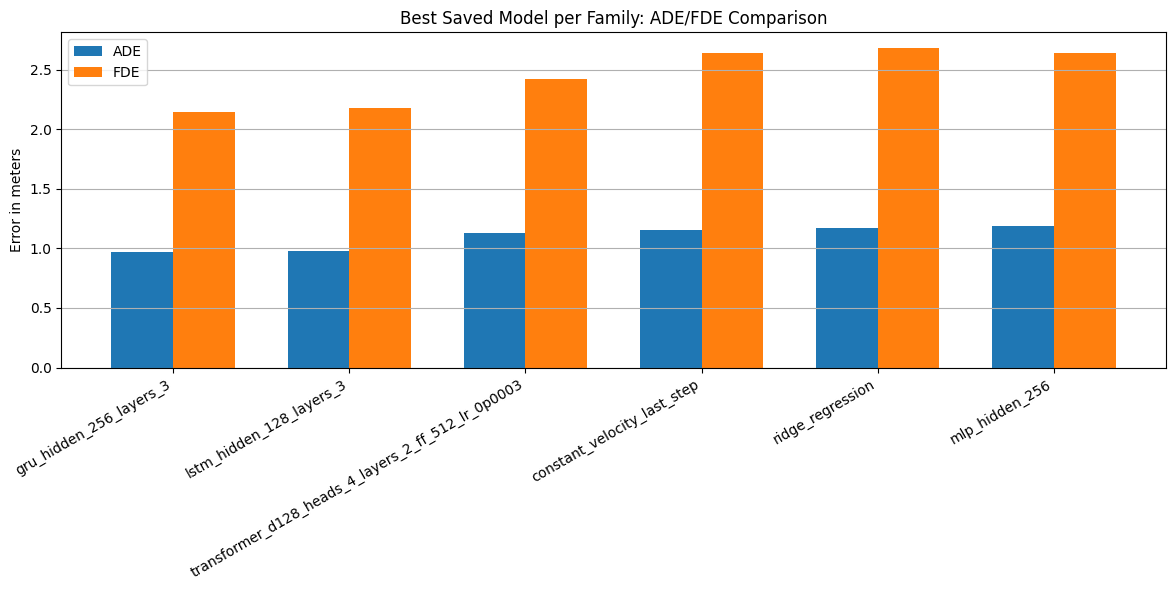

'/workspaces/nuscenes_trajectory_demo/outputs/final_report/best_saved_model_family_comparison.png'

In [22]:
plot_df = best_ade_by_group.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width / 2, plot_df["ade"], width, label="ADE")
plt.bar(x + width / 2, plot_df["fde"], width, label="FDE")

plt.xticks(x, plot_df["display_method"], rotation=30, ha="right")
plt.ylabel("Error in meters")
plt.title("Best Saved Model per Family: ADE/FDE Comparison")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "best_saved_model_family_comparison.png")
plt.savefig(save_path, dpi=200)
plt.show()

save_path

### Full ranking plot

This plot shows all saved configurations ranked by ADE.

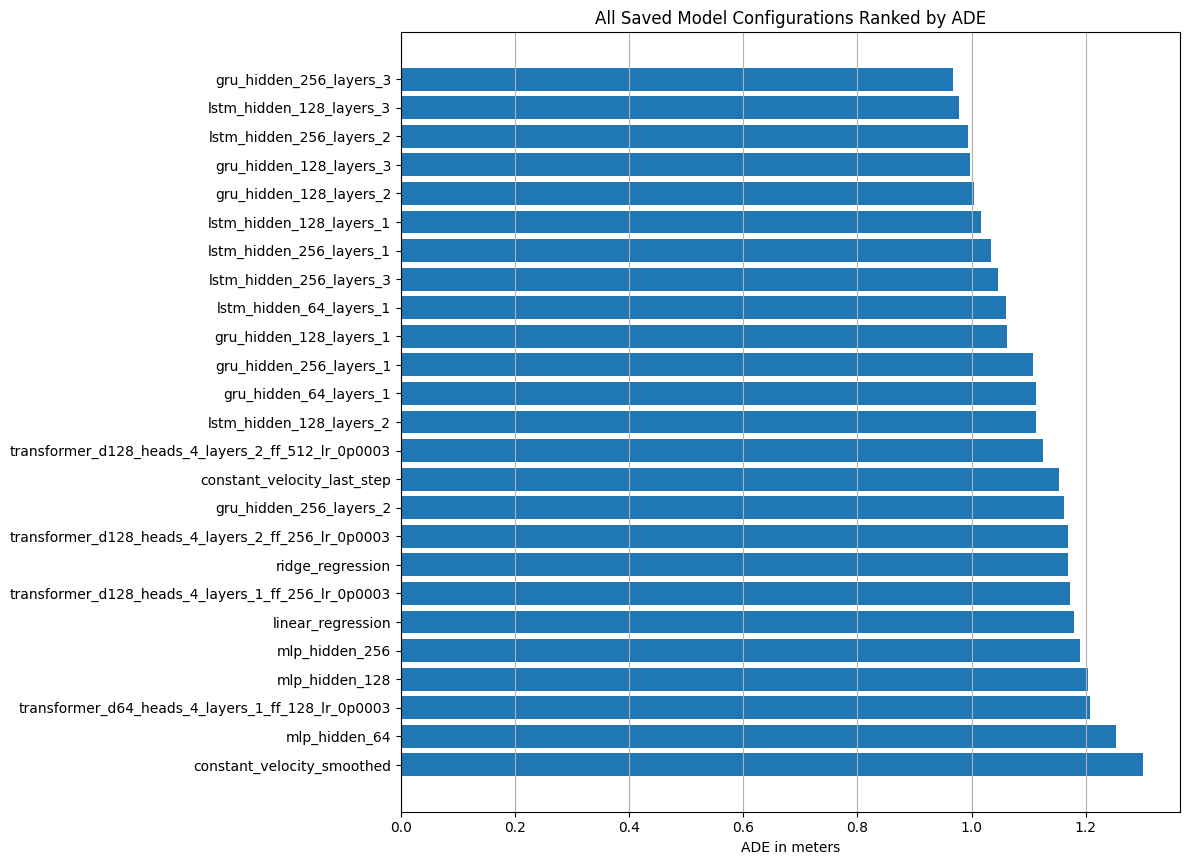

'/workspaces/nuscenes_trajectory_demo/outputs/final_report/all_saved_models_ranked_by_ade.png'

In [23]:
ranked_df = combined_df.sort_values("ade").reset_index(drop=True)

plt.figure(figsize=(12, max(6, 0.35 * len(ranked_df))))

y = np.arange(len(ranked_df))

plt.barh(y, ranked_df["ade"], label="ADE")
plt.yticks(y, ranked_df["display_method"])
plt.xlabel("ADE in meters")
plt.title("All Saved Model Configurations Ranked by ADE")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "all_saved_models_ranked_by_ade.png")
plt.savefig(save_path, dpi=200)
plt.show()

save_path

### Saved trajectory plots side-by-side

This section displays the saved PNG trajectory plots from each script.

In [24]:
def list_sample_ids_for_method(method_group, method_name):
    pattern = os.path.join(
        PLOTS_ROOT,
        method_group,
        f"*{method_name}*sample_*.png"
    )
    paths = glob.glob(pattern)

    sample_ids = []
    for path in paths:
        match = re.search(r"sample_(\d+)\.png$", os.path.basename(path))
        if match:
            sample_ids.append(int(match.group(1)))

    return sorted(set(sample_ids))


def find_saved_plot(method_group, method_name, sample_id):
    pattern = os.path.join(
        PLOTS_ROOT,
        method_group,
        f"*{method_name}*sample_{sample_id}.png"
    )

    matches = glob.glob(pattern)

    if len(matches) == 0:
        return None

    return matches[0]


def build_method_specs_from_best_ade(best_df):
    preferred_order = [
        "constant_velocity",
        "linear_regression",
        "mlp",
        "gru",
        "lstm",
        "transformer",
    ]

    specs = []

    for group in preferred_order:
        rows = best_df[best_df["model_group"] == group]

        if len(rows) == 0:
            continue

        row = rows.iloc[0]
        specs.append(
            {
                "model_group": row["model_group"],
                "method_name": row["raw_method"],
                "display_name": row["display_method"],
            }
        )

    return specs


method_specs = build_method_specs_from_best_ade(best_ade_by_group)
method_specs

[{'model_group': 'constant_velocity',
  'method_name': 'constant_velocity_last_step',
  'display_name': 'constant_velocity_last_step'},
 {'model_group': 'linear_regression',
  'method_name': 'ridge_regression',
  'display_name': 'ridge_regression'},
 {'model_group': 'mlp',
  'method_name': 'mlp_hidden_256',
  'display_name': 'mlp_hidden_256'},
 {'model_group': 'gru',
  'method_name': 'gru_hidden_256_layers_3',
  'display_name': 'gru_hidden_256_layers_3'},
 {'model_group': 'lstm',
  'method_name': 'lstm_hidden_128_layers_3',
  'display_name': 'lstm_hidden_128_layers_3'},
 {'model_group': 'transformer',
  'method_name': 'transformer_d128_heads_4_layers_2_ff_512_lr_0p0003',
  'display_name': 'transformer_d128_heads_4_layers_2_ff_512_lr_0p0003'}]

In [25]:
# Find sample IDs that exist for all selected methods.
sample_sets = []

for spec in method_specs:
    sample_ids = list_sample_ids_for_method(spec["model_group"], spec["method_name"])
    sample_sets.append(set(sample_ids))
    print(spec["display_name"], "sample IDs:", sample_ids)

common_sample_ids = sorted(set.intersection(*sample_sets)) if len(sample_sets) > 0 else []

print("\nCommon sample IDs:", common_sample_ids)

if len(common_sample_ids) == 0:
    raise ValueError(
        "No common sample IDs found across the selected methods. "
        "This can happen if some scripts used different plot sample IDs."
    )

constant_velocity_last_step sample IDs: [577, 1118, 1839, 1968, 2371]
ridge_regression sample IDs: [577, 1118, 1839, 1968, 2371]
mlp_hidden_256 sample IDs: [577, 1118, 1839, 1968, 2371]
gru_hidden_256_layers_3 sample IDs: [577, 1118, 1839, 1968, 2371]
lstm_hidden_128_layers_3 sample IDs: [577, 1118, 1839, 1968, 2371]
transformer_d128_heads_4_layers_2_ff_512_lr_0p0003 sample IDs: [577, 1118, 1839, 1968, 2371]

Common sample IDs: [577, 1118, 1839, 1968, 2371]


In [26]:
def show_saved_plots_side_by_side(sample_id, method_specs):
    n = len(method_specs)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, spec in zip(axes, method_specs):
        method_group = spec["model_group"]
        method_name = spec["method_name"]
        display_name = spec["display_name"]

        path = find_saved_plot(method_group, method_name, sample_id)

        ax.axis("off")

        if path is None:
            ax.set_title(f"{display_name}\nMissing plot")
            continue

        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(display_name)

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(f"Saved trajectory plots for sample {sample_id}", fontsize=16)
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, f"saved_side_by_side_sample_{sample_id}.png")
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    return save_path

In [27]:
# Pick up to 5 common samples, evenly spread.
positions = np.linspace(
    0,
    len(common_sample_ids) - 1,
    min(5, len(common_sample_ids)),
    dtype=int
)

selected_sample_ids = [common_sample_ids[pos] for pos in positions]

selected_sample_ids

[577, 1118, 1839, 1968, 2371]

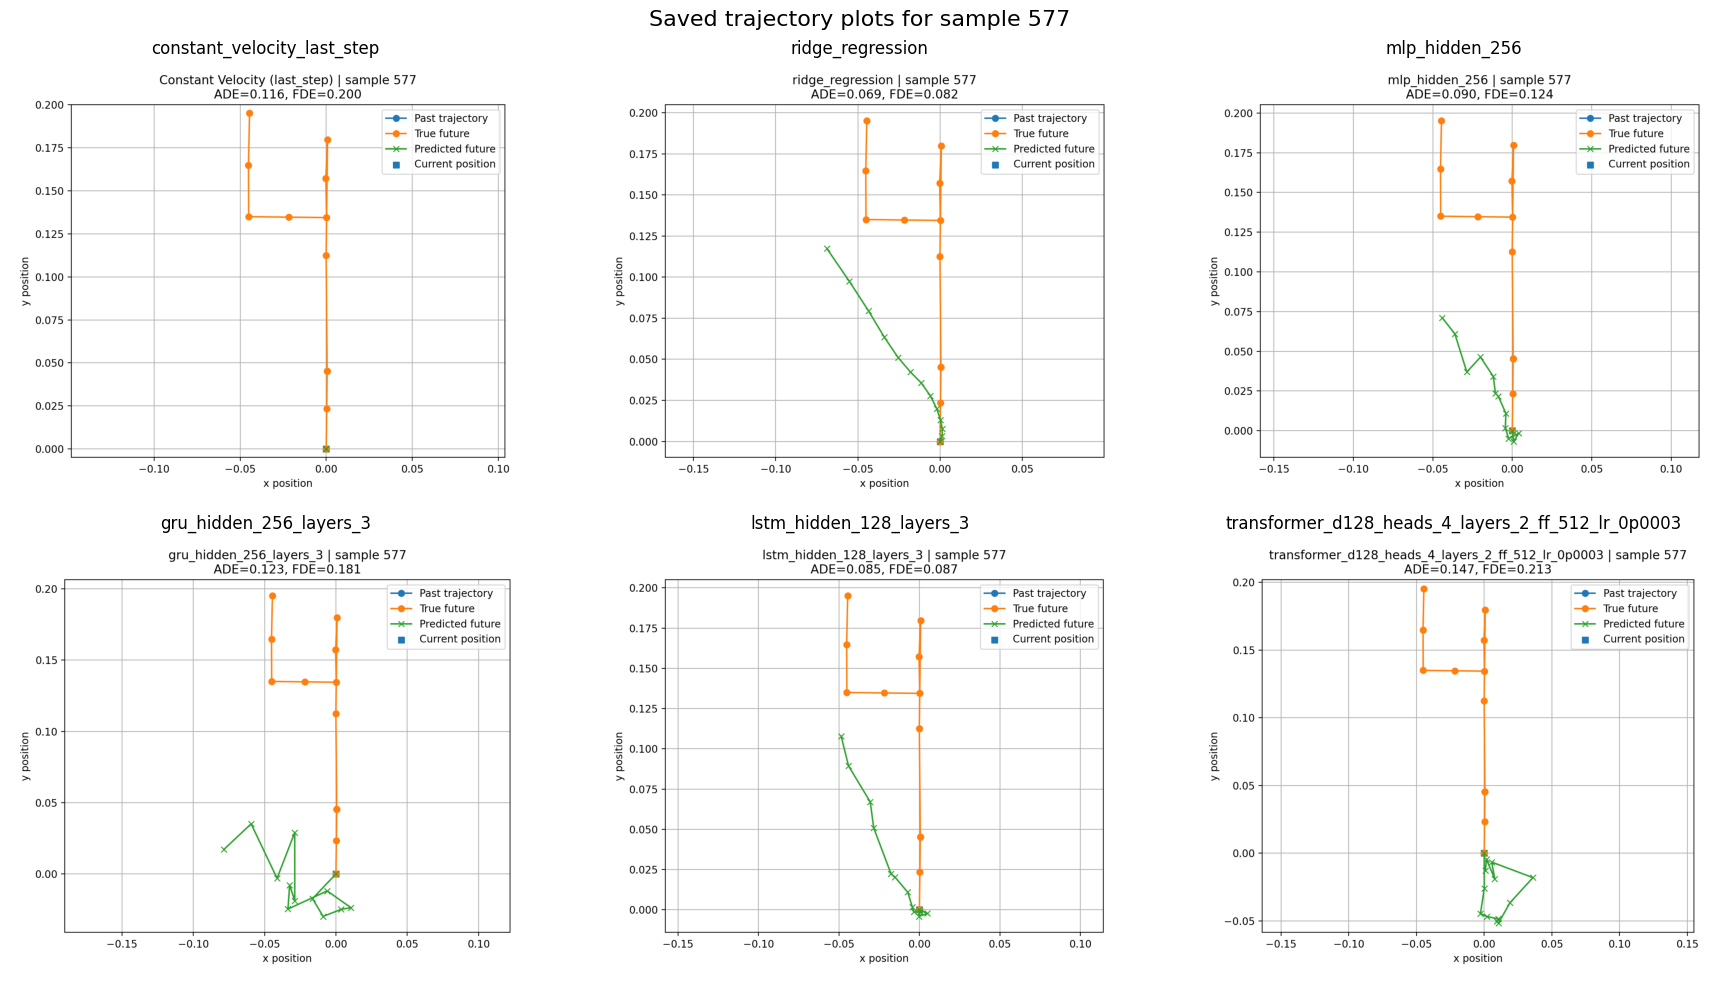

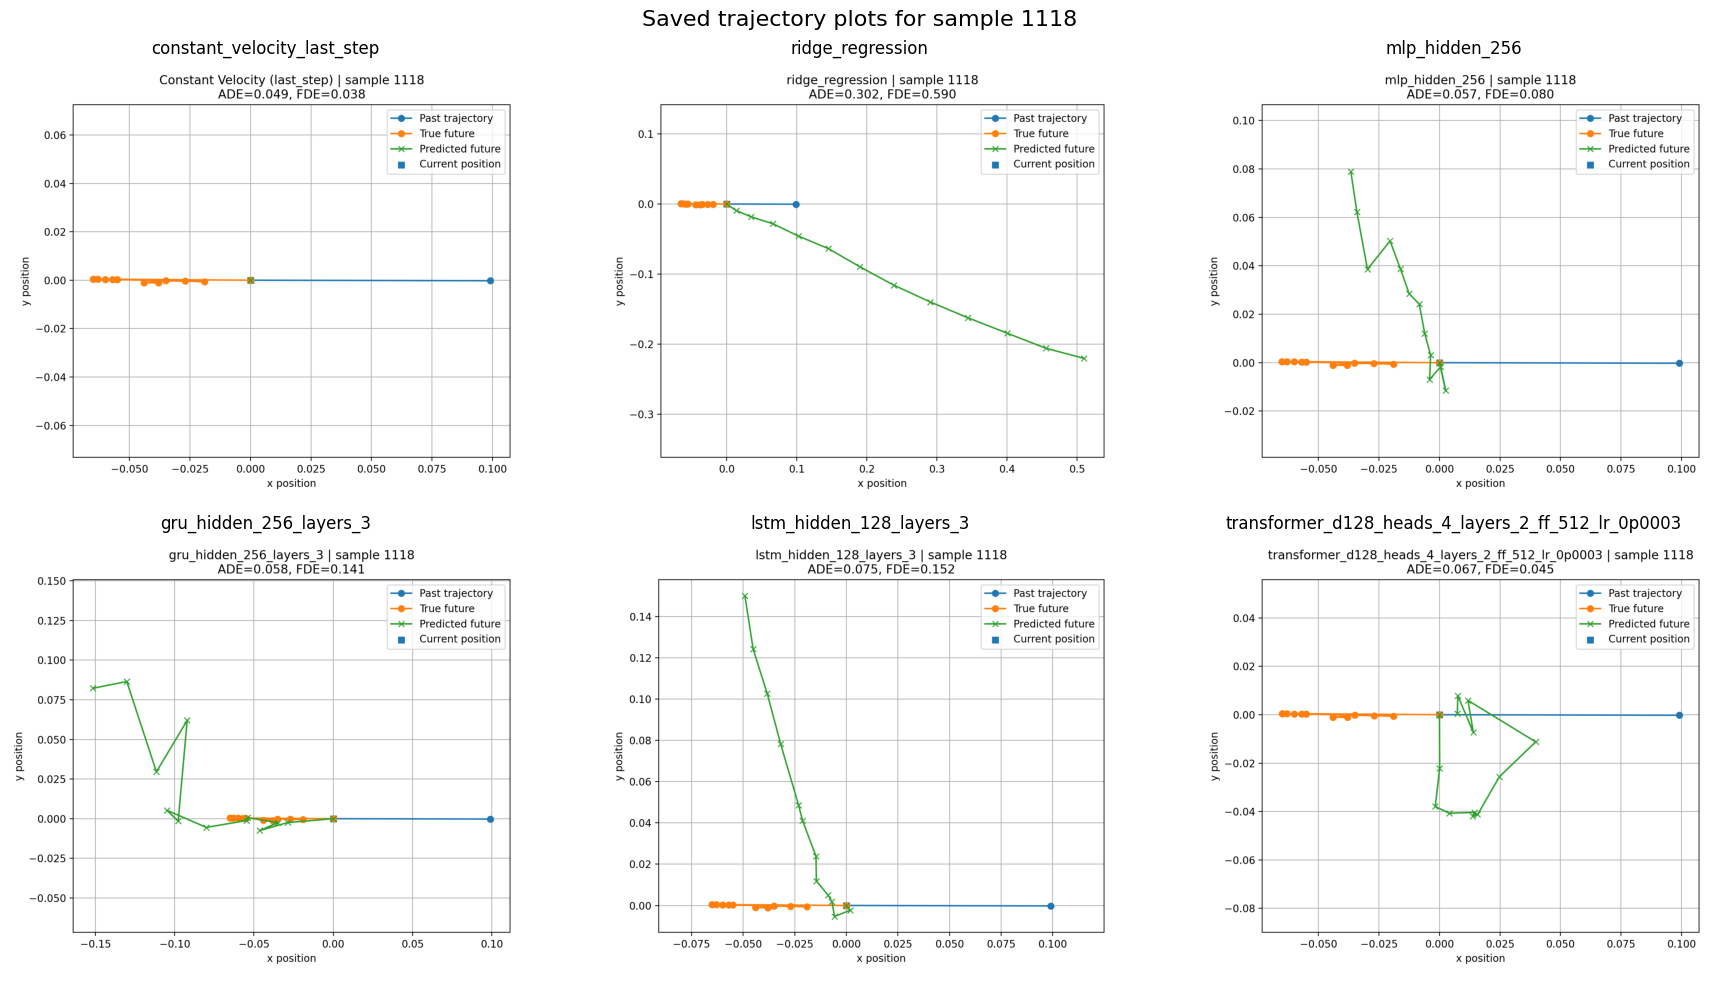

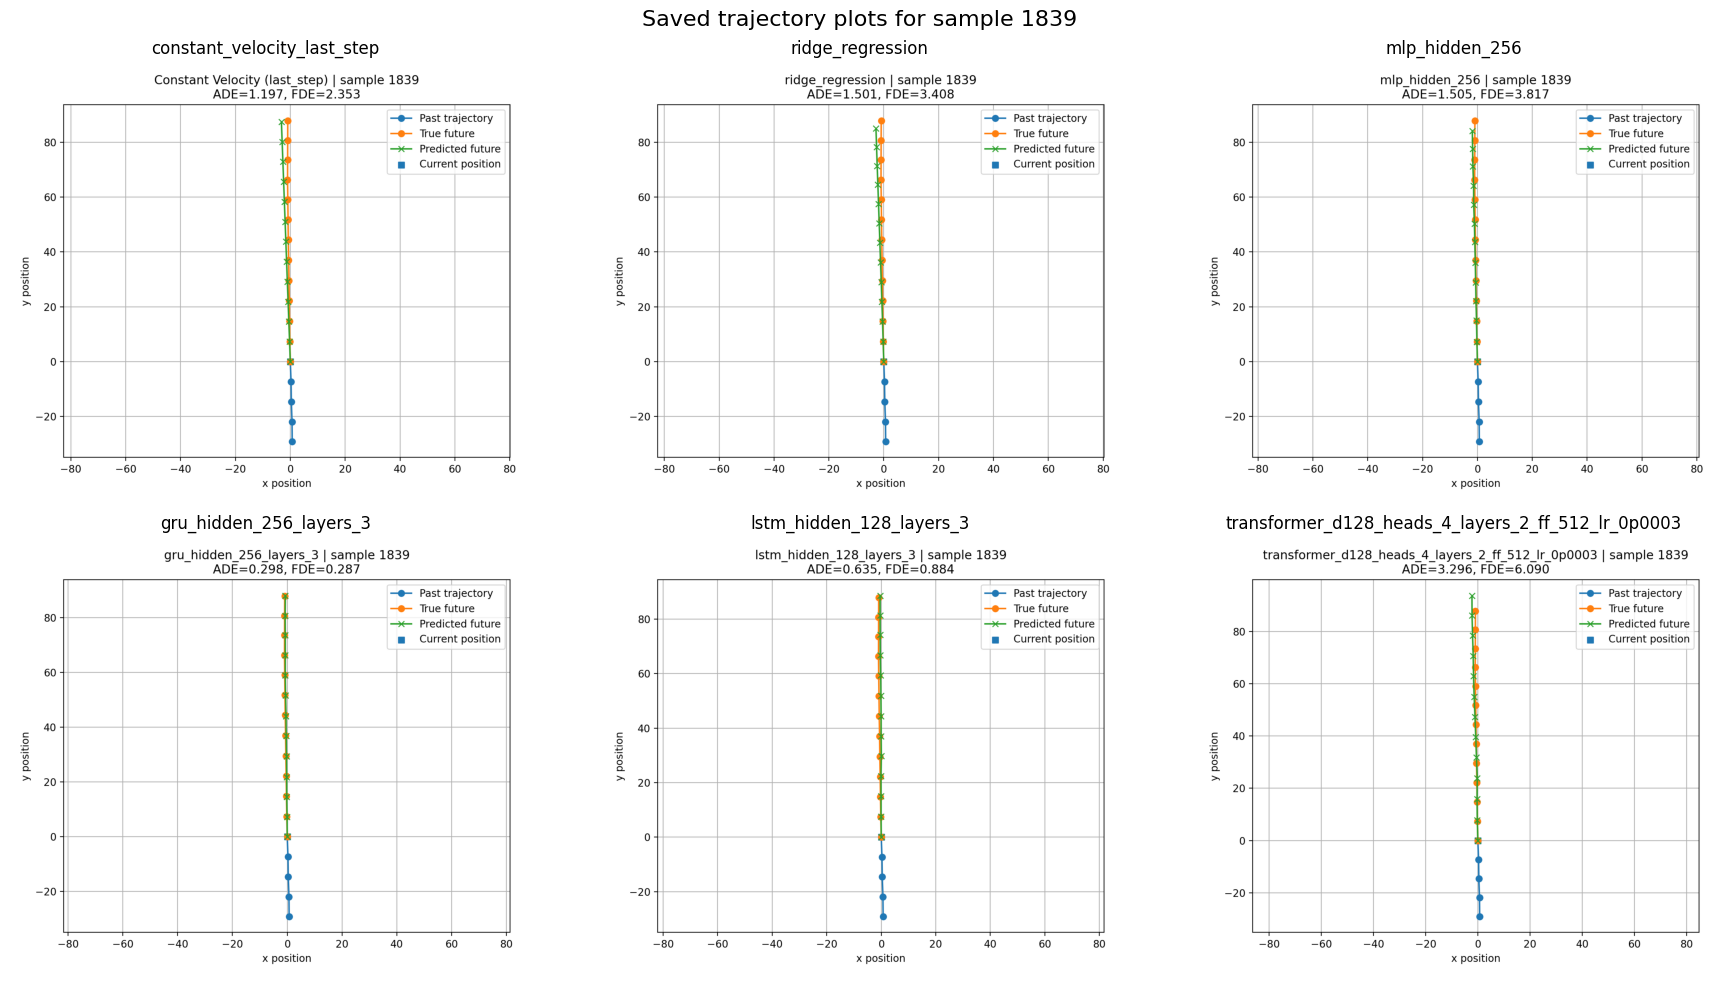

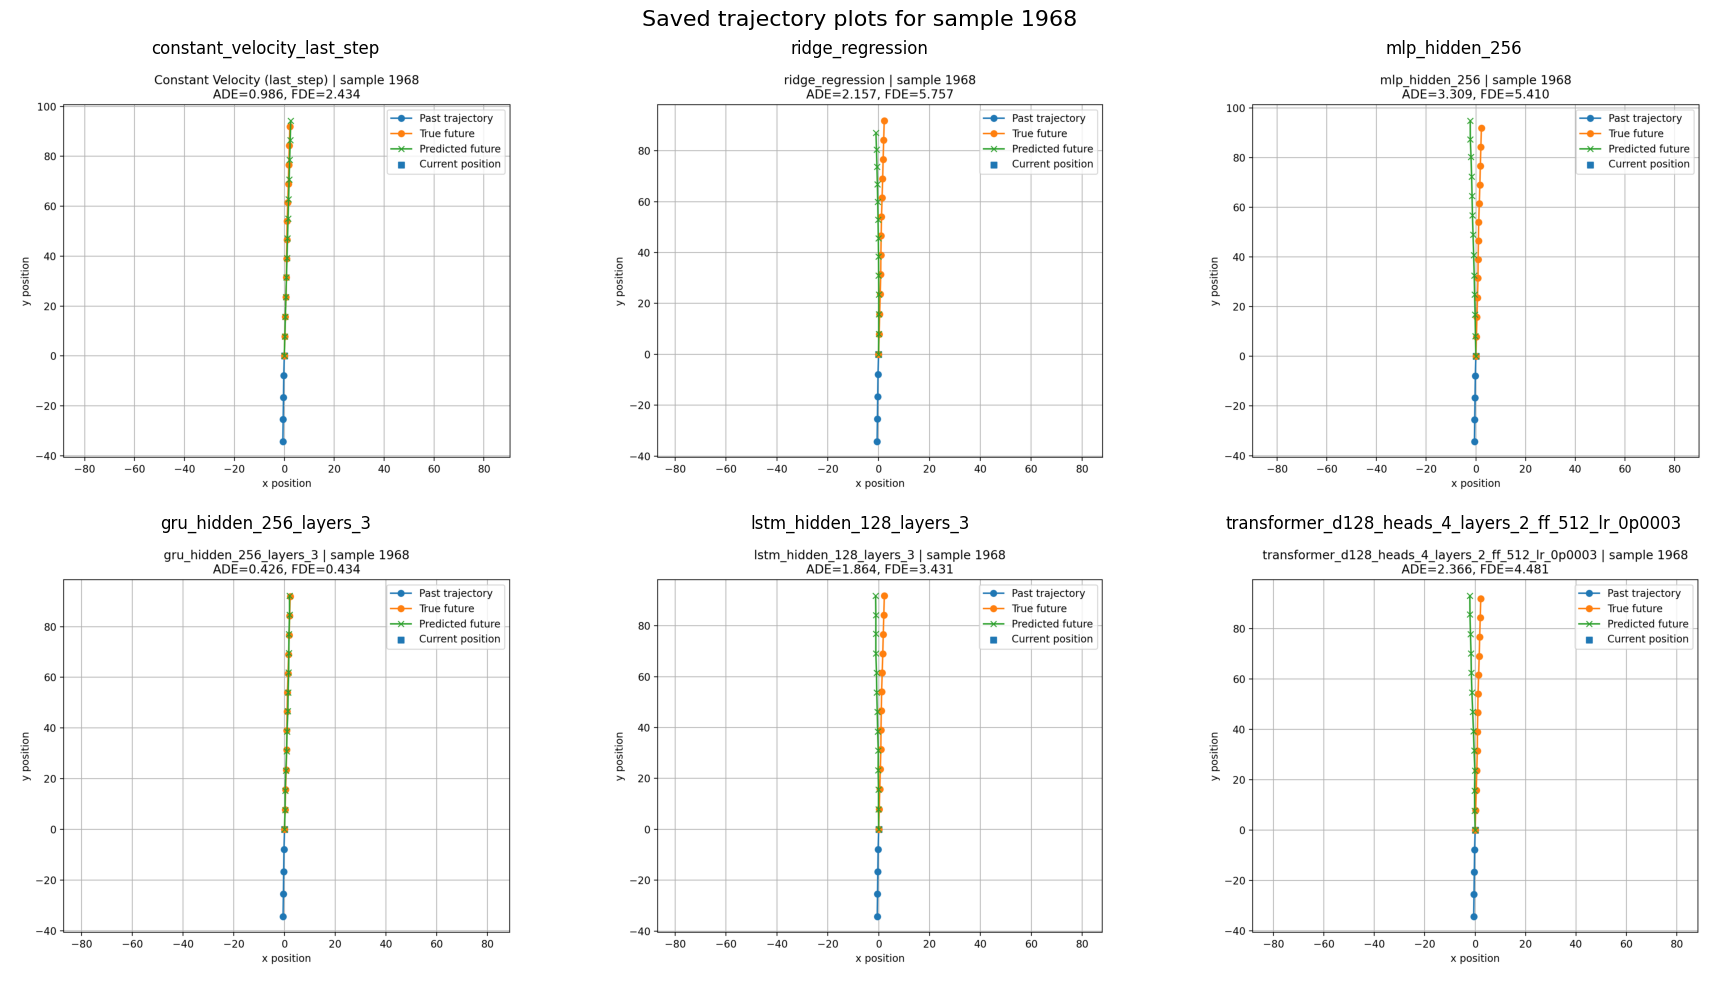

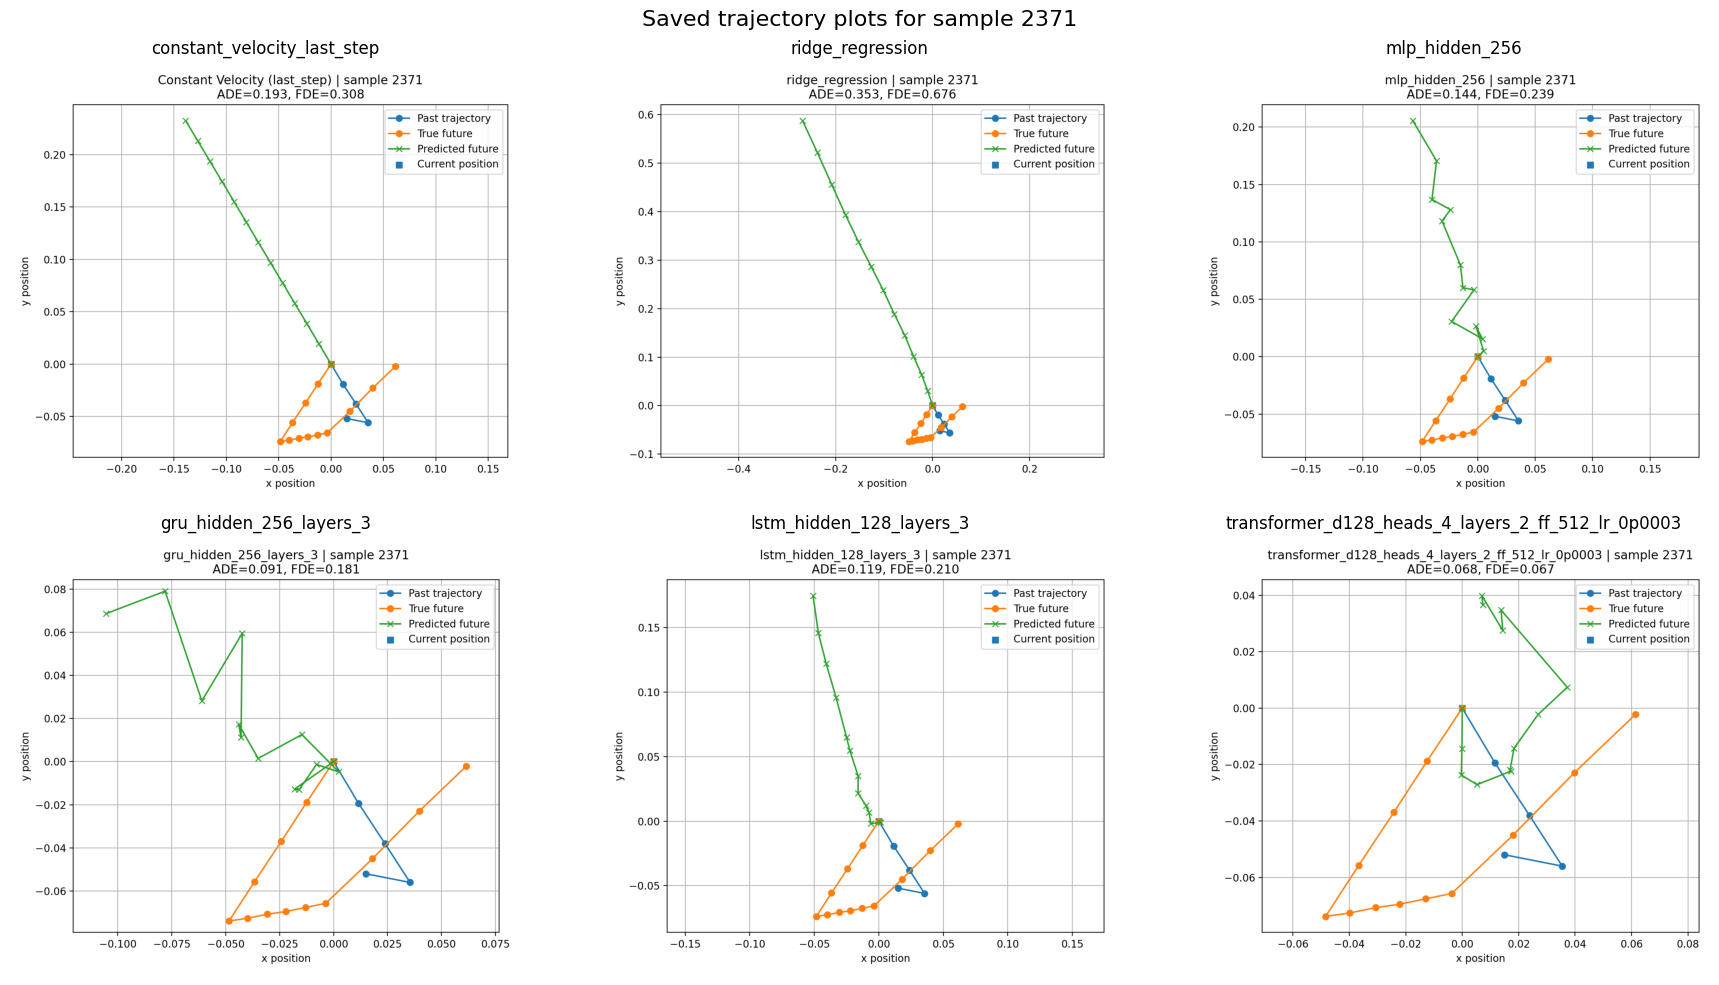

['/workspaces/nuscenes_trajectory_demo/outputs/final_report/saved_side_by_side_sample_577.png',
 '/workspaces/nuscenes_trajectory_demo/outputs/final_report/saved_side_by_side_sample_1118.png',
 '/workspaces/nuscenes_trajectory_demo/outputs/final_report/saved_side_by_side_sample_1839.png',
 '/workspaces/nuscenes_trajectory_demo/outputs/final_report/saved_side_by_side_sample_1968.png',
 '/workspaces/nuscenes_trajectory_demo/outputs/final_report/saved_side_by_side_sample_2371.png']

In [28]:
saved_side_by_side_paths = []

for sample_id in selected_sample_ids:
    path = show_saved_plots_side_by_side(sample_id, method_specs)
    saved_side_by_side_paths.append(path)

saved_side_by_side_paths